# Competition 1: Beer Quality Prediction 🍺

This notebook provides starter code for the Beer Quality Prediction competition. For full instructions, problem statement, and grading criteria, please refer to the **README.md** file.

**Quick Summary**: You will build a classification model to predict beer quality (scores 1-10) based on chemical properties. Submit your predictions to [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Import Dependencies

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Explore Data

In [2]:
# Load the training and test data
train_df = pd.read_csv('data/train.csv', delimiter=';')

# Training Data 
print(f"Training data shape: {train_df.shape}")
print(f"Number of samples (n): {train_df.shape[0]}")
print(f"Number of features (d): {train_df.shape[1] - 1}")  # Subtract 1 for target column
print(f"Columns: {list(train_df.columns)}")
print("\nFirst few rows:")
print(train_df.head())

# Check data types and basic info
print("\nData types and info for train df:")
print(train_df.info())


Training data shape: (4469, 15)
Number of samples (n): 4469
Number of features (d): 14
Columns: ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

First few rows:
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0       Pale           7.997                   0.446        0.280   
1   1       Pale           6.906                   0.222        0.303   
2   2      Brown           7.183                   0.636        0.071   
3   3       Pale           6.403                   0.242        0.260   
4   4      Brown           7.917                   0.182        0.347   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0         10.803   0.052    24.999           157.026             0.995  3.057   
1          6.305   0.034    40.993           130.993  

In [3]:
test_df = pd.read_csv('data/test.csv', delimiter=';')

# Test Data 
print(f"Test data shape: {test_df.shape}")
print(f"Number of samples (n): {test_df.shape[0]}")
print(f"Columns: {list(test_df.columns)}")
print("\nFirst few rows:")
print(test_df.head())


# Check data types and basic info
print("\nData types and info for test df:")
print(test_df.info())

Test data shape: (511, 14)
Number of samples (n): 511
Columns: ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength']

First few rows:
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0     Golden           7.904                   0.419        0.501   
1   1       Pale           6.317                   0.223        0.575   
2   2     Golden           5.483                   0.347        0.254   
3   3       Pale           5.183                   0.515        0.166   
4   4       Dark          13.505                   0.527        0.792   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0          8.200   0.074    31.994           163.998             0.989  3.310   
1          9.995   0.094    33.990           126.001             1.001  2.953   
2          2.221 

In [4]:
## Data Exploration and Visualization Continued 
# Listing column names for train and test data 
print(train_df.columns)

# Printing summary statistics 
print("\n Summary Statistics")
display(train_df.describe())

# Data Type per feature 
print("\n Data Type per feature")
print(train_df.dtypes.value_counts)

# Defining Missing value per feature 
print("\n Missing Values summary statistics")
display(train_df.isnull().sum().sort_values(ascending=False))


Index(['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration',
       'lactic_acid', 'final_gravity', 'sodium', 'free_CO2',
       'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level',
       'alcohol_ABV', 'fermentation_strength', 'quality'],
      dtype='object')

 Summary Statistics


,id,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
count,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000
mean,2234.000000,7.235609,0.338640,0.317996,5.506593,0.055572,30.744267,116.383056,0.994855,3.217238,0.528450,4.986386,9.478692,5.811815
std,1290.233506,1.296424,0.163701,0.145221,4.741626,0.033916,18.011711,56.441889,0.010509,0.161431,0.143315,0.560061,0.892119,0.838949
min,0.000000,3.804000,0.064000,-0.022000,0.596000,-0.004000,0.998000,5.991000,0.957000,2.723000,0.216000,3.816000,7.429000,3.000000
25%,1117.000000,6.410000,0.226000,0.245000,1.805000,0.037000,16.999000,78.994000,0.988000,3.107000,0.430000,4.524000,8.778000,5.000000
50%,2234.000000,6.996000,0.293000,0.308000,3.119000,0.049000,29.001000,118.997000,0.995000,3.205000,0.506000,4.904000,9.348000,6.000000
75%,3351.000000,7.697000,0.404000,0.393000,8.196000,0.067000,41.984000,156.000000,1.002000,3.320000,0.598000,5.382000,10.109000,6.000000
max,4468.000000,15.885000,1.572000,1.672000,31.612000,0.603000,288.995000,440.004000,1.032000,4.006000,1.989000,7.096000,12.648000,9.000000



 Data Type per feature
<bound method IndexOpsMixin.value_counts of id                          int64
beer_style                 object
bitterness_IBU            float64
diacetyl_concentration    float64
lactic_acid               float64
final_gravity             float64
sodium                    float64
free_CO2                  float64
dissolved_oxygen          float64
original_gravity          float64
pH                        float64
gypsum_level              float64
alcohol_ABV               float64
fermentation_strength     float64
quality                     int64
dtype: object>

 Missing Values summary statistics


id                        0
beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64

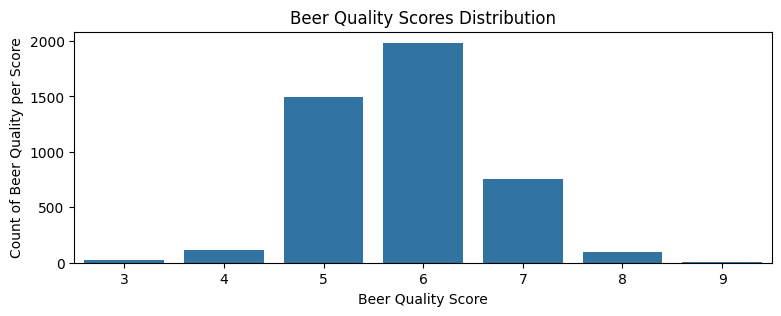

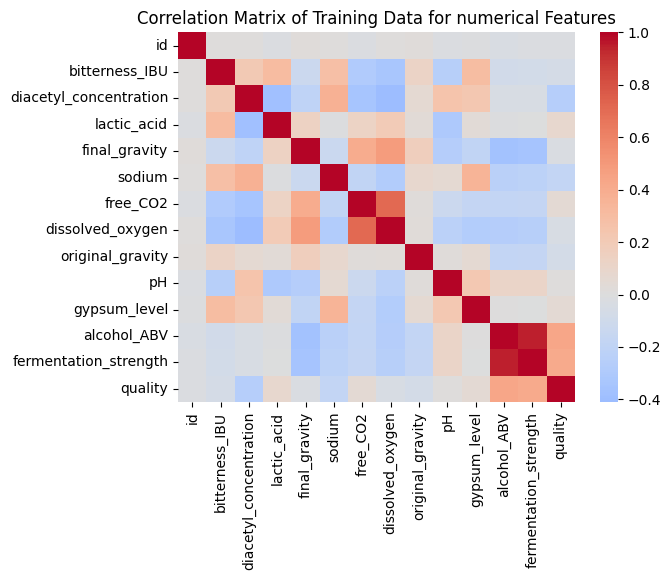

In [5]:
## Data Visualization and Exploring
## Visualizing Target variables
plt.figure(figsize=(9,3))
sns.countplot(x="quality",data=train_df)
plt.title("Beer Quality Scores Distribution")
plt.xlabel("Beer Quality Score")
plt.ylabel("Count of Beer Quality per Score")
plt.show()

## Plotting Correlation Matrix for numerical Features 
features = train_df.select_dtypes(include=["float64", "int64"]).columns
sns.heatmap(train_df[features].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Training Data for numerical Features")
plt.show()

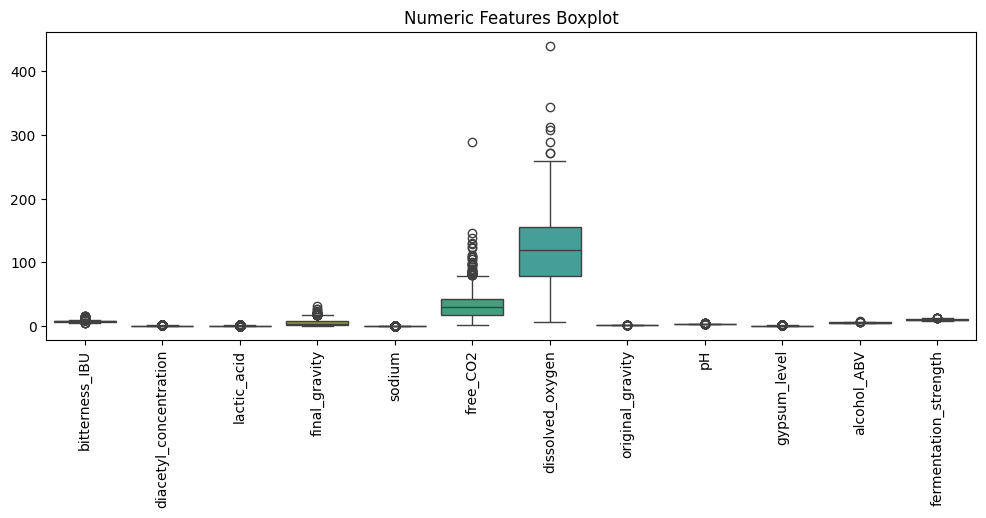

In [6]:
## Detecting Outliers for feature columns 
plt.figure(figsize=(12,4))
sns.boxplot(data=train_df[features.drop(["id", "quality"], errors='ignore')])
plt.xticks(rotation=90)
plt.title("Numeric Features Boxplot")
plt.show()

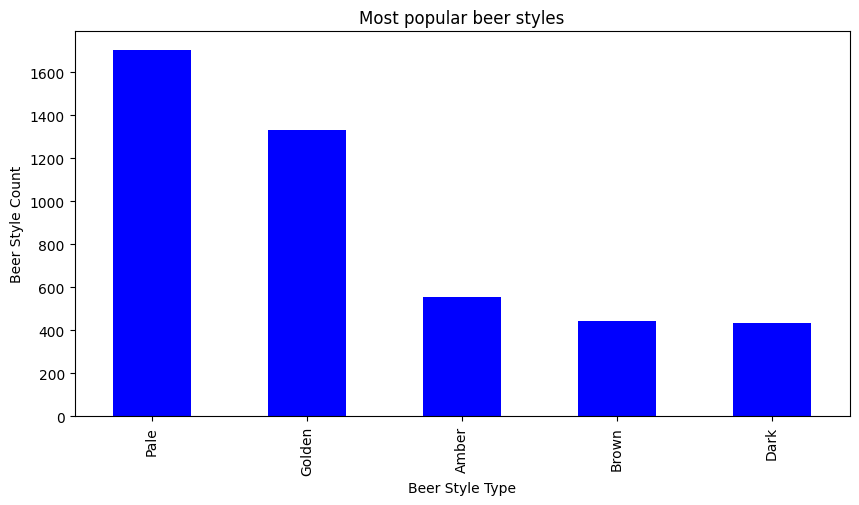

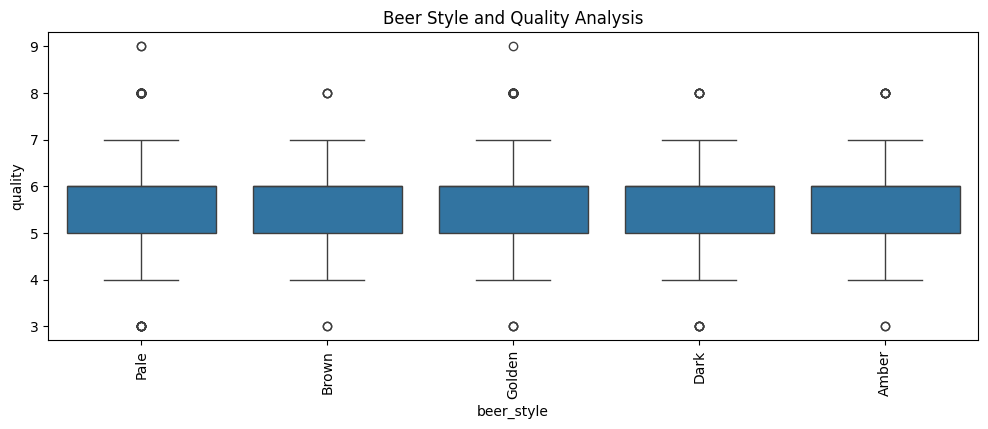

In [7]:
## Analyzing Categorial feature - Beer Style column 
plt.figure(figsize=(10,5))
train_df["beer_style"].value_counts().head().plot(kind="bar", color="blue")
plt.title("Most popular beer styles")
plt.xlabel("Beer Style Type")
plt.ylabel("Beer Style Count")
plt.show()

## Analyzing Beer Stlye relationship with Target 
plt.figure(figsize=(12,4))
sns.boxplot(x="beer_style", y="quality", data=train_df)
plt.xticks(rotation=90)
plt.title("Beer Style and Quality Analysis")
plt.show()

## Data Preprocessing

Implement your preprocessing pipeline (see README.md for suggestions).

In [8]:
# First copy the data frames to avoid modifying the original data frames
df_train = train_df.copy()
df_test = test_df.copy()

# Investigate missing values
print("Investigating the missing values before imputation.")
print(train_df.isnull().sum().sort_values(ascending=False))

# Fill numeric columns
# Identify numeric columns (exclude 'quality' if present)
numeric_cols = [col for col in df_train.select_dtypes(include=["float64", "int64"]).columns if col != "quality"]

for col in numeric_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())
    df_test[col] = df_test[col].fillna(df_train[col].median())

# Fill categorical column
df_train["beer_style"] = df_train["beer_style"].fillna(df_train["beer_style"].mode()[0])
df_test["beer_style"] = df_test["beer_style"].fillna(df_train["beer_style"].mode()[0])

# Print results
print("\n Missing values after imputations for Training data:")
print(df_train.isnull().sum().sum())

print("\n Missing values after imputations for Testing data:")
print(df_test.isnull().sum().sum())











Investigating the missing values before imputation.
id                        0
beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64

 Missing values after imputations for Training data:
0

 Missing values after imputations for Testing data:
0


In [9]:
# Function to safely set 'id' as index for any DataFrame
def set_id_index(df, name="DataFrame"):
    print(f"\nProcessing {name}...")
    first_col = df.columns[0]
    print(f"First column in {name}: {first_col}")

    # Drop unnecessary unnamed/index columns
    if first_col.lower() in ["unnamed: 0", "index"]:
        df = df.drop(columns=[first_col])
        print(f"Dropped redundant column '{first_col}'.")

    # Set 'id' as index if it exists
    if 'id' in df.columns:
        df = df.set_index('id')
        print(f" 'id' set as index for {name}.")
    else:
        print(f"Warning: 'id' column not found in {name}. It may already be the index.")

    print(f"{name} shape: {df.shape}")
    print(f"Index name: {df.index.name}\n")
    return df


# Apply to both training and test DataFrames
df_train = set_id_index(df_train, "Training DataFrame")
df_test = set_id_index(df_test, "Test DataFrame")



Processing Training DataFrame...
First column in Training DataFrame: id
 'id' set as index for Training DataFrame.
Training DataFrame shape: (4469, 14)
Index name: id


Processing Test DataFrame...
First column in Test DataFrame: id
 'id' set as index for Test DataFrame.
Test DataFrame shape: (511, 13)
Index name: id



In [10]:
## Encoding Categorical Variables 
label_enc = LabelEncoder()
df_train["beer_style"] = label_enc.fit_transform(df_train["beer_style"])
df_test["beer_style"] = label_enc.transform(df_test["beer_style"])

print("\nBeer Styles encoded as integers")
print(label_enc.classes_)


Beer Styles encoded as integers
['Amber' 'Brown' 'Dark' 'Golden' 'Pale']


In [11]:
#numeric_cols = [col for col in df_train.select_dtypes(include=["float64", "int64"]).columns if col != "quality"]

# Scaling Columns for both Train and Test 
#scaling_factor = StandardScaler()

#df_train[numeric_cols] = scaling_factor.fit_transform(df_train[numeric_cols])
#df_test[numeric_cols] = scaling_factor.transform(df_test[numeric_cols])

#print("\nScaling Completed Successfully")


In [12]:
## Correlation:
## Printing the Top Correlated Features with quality 
correlation = df_train.corr()["quality"].sort_values(ascending=False)
print("\nTop Correlated Featurs: ")
print(correlation.head(15))


Top Correlated Featurs: 
quality                   1.000000
alcohol_ABV               0.431341
fermentation_strength     0.413183
lactic_acid               0.084787
gypsum_level              0.050557
free_CO2                  0.048471
beer_style                0.044510
pH                        0.010023
final_gravity            -0.025243
dissolved_oxygen         -0.043244
bitterness_IBU           -0.066856
original_gravity         -0.070534
sodium                   -0.181036
diacetyl_concentration   -0.258663
Name: quality, dtype: float64


In [13]:
## Dropping columns with negative correlation with quality from training and test set 
drop_cols = []

df_train.drop(columns=drop_cols, inplace=True, errors="ignore")
df_test.drop(columns=drop_cols, inplace=True, errors="ignore")


In [14]:
## Final Analysis of Results after preprocessing 
print("\nTraining data shape")
print(df_train.shape)
print("\nTraining data types")
print(df_train.dtypes)
print("\nTest data shape")
print(df_test.shape)


Training data shape
(4469, 14)

Training data types
beer_style                  int64
bitterness_IBU            float64
diacetyl_concentration    float64
lactic_acid               float64
final_gravity             float64
sodium                    float64
free_CO2                  float64
dissolved_oxygen          float64
original_gravity          float64
pH                        float64
gypsum_level              float64
alcohol_ABV               float64
fermentation_strength     float64
quality                     int64
dtype: object

Test data shape
(511, 13)


## Prepare Training and Validation Data

Split your data into training and validation sets.

In [17]:
## Splitting Data into Train and Test Validation Sets: 
from sklearn.model_selection import train_test_split
# Defining features and labels
# Features will be all retained columns except quality, and labels column is quality
X = df_train.drop(columns=["quality"], errors="ignore")
y = df_train["quality"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##Printing Training and Training and Validation Set Sizes: 
print(f"Training set sizes for X_train (features) are: {X_train.shape}, Training set sizes for y_train (labels): {y_train.shape}")
print(f"Validation set sizes for X_val (features) are:   {X_val.shape}, Training set sizes for y_val (labels):   {y_val.shape}")


Training set sizes for X_train (features) are: (3575, 13), Training set sizes for y_train (labels): (3575,)
Validation set sizes for X_val (features) are:   (894, 13), Training set sizes for y_val (labels):   (894,)


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [8, 12, 16, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    rf, param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Validation Accuracy:", best_rf.score(X_val, y_val))



Fitting 3 folds for each of 432 candidates, totalling 1296 fits


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best params: {'criterion': 'entropy', 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Validation Accuracy: 0.616331096196868



🚀 Starting optimized model training loop...

🧩 Training Complement Naive Bayes...
✅ Complement Naive Bayes: Accuracy=0.424, F1=0.349
🧩 Training Gaussian Naive Bayes...
✅ Gaussian Naive Bayes: Accuracy=0.483, F1=0.469
🧩 Training Ridge Classifier (alpha=0.3)...
✅ Ridge Classifier (alpha=0.3): Accuracy=0.532, F1=0.471
🧩 Training SGD Classifier (Elastic Net)...
✅ SGD Classifier (Elastic Net): Accuracy=0.436, F1=0.362
🧩 Training QDA (reg=0.05)...
✅ QDA (reg=0.05): Accuracy=0.507, F1=0.506
🧩 Training KNN (k=4, dist)...
✅ KNN (k=4, dist): Accuracy=0.569, F1=0.557
🧩 Training KNN (k=8, dist)...
✅ KNN (k=8, dist): Accuracy=0.572, F1=0.554
🧩 Training Parzen Window (k=16)...


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 6 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


✅ Parzen Window (k=16): Accuracy=0.566, F1=0.545
🧩 Training Histogram Approximation (k=20)...
✅ Histogram Approximation (k=20): Accuracy=0.573, F1=0.549

📊 Final Results Summary:


,Classifier,Accuracy,Precision,Recall,F1-Score
8,Histogram Approximation (k=20),0.572707,0.538396,0.572707,0.549450
6,"KNN (k=8, dist)",0.571588,0.540877,0.571588,0.554304
5,"KNN (k=4, dist)",0.569351,0.551128,0.569351,0.556681
7,Parzen Window (k=16),0.565996,0.531373,0.565996,0.544573
2,Ridge Classifier (alpha=0.3),0.532438,0.518926,0.532438,0.470547
4,QDA (reg=0.05),0.506711,0.511470,0.506711,0.506379
1,Gaussian Naive Bayes,0.483221,0.480763,0.483221,0.468558
3,SGD Classifier (Elastic Net),0.436242,0.469671,0.436242,0.361534
0,Complement Naive Bayes,0.423937,0.484434,0.423937,0.349250



🤝 Building soft-voting ensemble of: ['Histogram Approximation (k=20)', 'KNN (k=8, dist)', 'KNN (k=4, dist)']
🏆 Ensemble Accuracy=0.589, F1=0.569


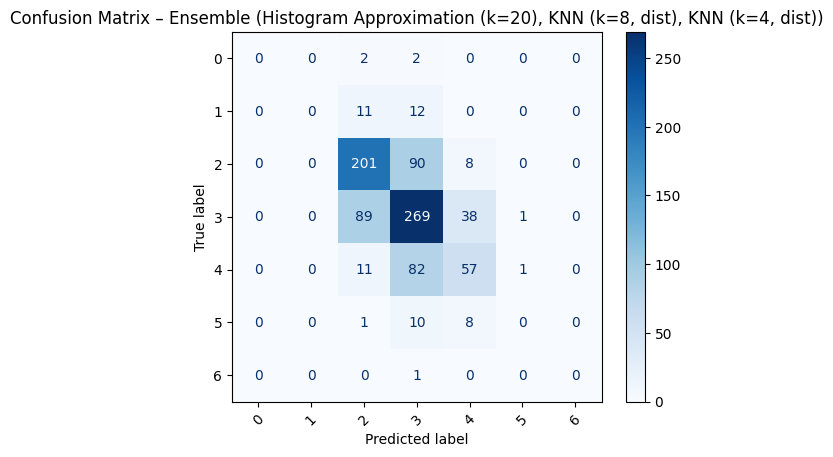


📤 Generating Kaggle submission...
✅ Saved → predicted_quality_V5.csv


In [27]:
# ===============================================================
# ⚡️ L U C I U S  C O D E  V 5  —  F A S T  +  M O R E  A C C U R A T E
# ===============================================================
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import ComplementNB, GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import RidgeClassifier, SGDClassifier
from sklearn.ensemble import VotingClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================================
# 🔹 MODEL DEFINITIONS (Enhanced Accuracy + Fast Execution)
# ===============================================================

classifiers = [
    # --- Bayes Models (low variance, fast) ---
    ComplementNB(alpha=0.5),               # slightly reduced alpha = less bias
    GaussianNB(var_smoothing=1e-4),        # stronger smoothing improves generalization

    # --- Linear Models ---
    RidgeClassifier(alpha=0.3, solver='lsqr'),   # lower alpha = higher capacity
    SGDClassifier(loss="modified_huber", penalty="elasticnet",
                  alpha=5e-5, l1_ratio=0.3, max_iter=800,
                  tol=1e-3, random_state=42),

    # --- Quadratic Discriminant (Bayes boundary) ---
    QDA(reg_param=0.05),                   # lighter regularization for more flexible fit

    # --- Parzen Window (Gaussian-weighted KNN variants) ---
    KNeighborsClassifier(n_neighbors=4, weights='distance', p=2),
    KNeighborsClassifier(n_neighbors=8, weights='distance', p=2),
    KNeighborsClassifier(n_neighbors=16, weights='distance', p=2),  # Parzen-like
    KNeighborsClassifier(n_neighbors=20, weights='uniform', p=2),   # Histogram
]

classifier_names = [
    "Complement Naive Bayes",
    "Gaussian Naive Bayes",
    "Ridge Classifier (alpha=0.3)",
    "SGD Classifier (Elastic Net)",
    "QDA (reg=0.05)",
    "KNN (k=4, dist)",
    "KNN (k=8, dist)",
    "Parzen Window (k=16)",
    "Histogram Approximation (k=20)"
]

# ===============================================================
# 🔹 TRAINING + EVALUATION
# ===============================================================
results, trained_models = [], {}
print("\n🚀 Starting optimized model training loop...\n")

for name, clf in zip(classifier_names, classifiers):
    print(f"🧩 Training {name}...")
    try:
        # Adaptive scaler per model
        if "Naive Bayes" in name:
            model = make_pipeline(MinMaxScaler(), clf)
        elif "SGD" in name:
            model = make_pipeline(RobustScaler(), clf)
        else:
            model = make_pipeline(StandardScaler(), clf)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

        trained_models[name] = model
        results.append({
            "Classifier": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })
        print(f"✅ {name}: Accuracy={acc:.3f}, F1={f1:.3f}")

    except Exception as e:
        print(f"⚠️ Skipped {name}: {e}")

# ===============================================================
# 🔹 SUMMARIZE RESULTS
# ===============================================================
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n📊 Final Results Summary:")
display(results_df)

# ===============================================================
# 🔹 ENSEMBLE (Weighted Soft Voting of Top 3 Models)
# ===============================================================
top3 = results_df.head(3)["Classifier"].tolist()
print(f"\n🤝 Building soft-voting ensemble of: {top3}")

estimators = [(n, trained_models[n]) for n in top3]
weights = [3, 2, 1]  # higher weight to top performer
ensemble = VotingClassifier(estimators=estimators, voting='soft', weights=weights, n_jobs=-1)

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_val)

acc_ens = accuracy_score(y_val, y_pred_ens)
f1_ens = f1_score(y_val, y_pred_ens, average='weighted', zero_division=0)
print(f"🏆 Ensemble Accuracy={acc_ens:.3f}, F1={f1_ens:.3f}")

# ===============================================================
# 🔹 CONFUSION MATRIX
# ===============================================================
cm = confusion_matrix(y_val, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix – Ensemble ({', '.join(top3)})")
plt.show()

# ===============================================================
# 🔹 SUBMISSION
# ===============================================================
best_model = ensemble if acc_ens > results_df.iloc[0]["Accuracy"] else trained_models[results_df.iloc[0]["Classifier"]]
print("\n📤 Generating Kaggle submission...")

y_test_pred = best_model.predict(df_test[X_train.columns])
submission = pd.DataFrame({"id": df_test.index, "quality": y_test_pred})
submission.to_csv("predicted_quality_V5.csv", index=False)
print("✅ Saved → predicted_quality_V5.csv")


In [26]:
# ===============================================================
# ⚡️ L U C I U S  C O D E  V 7  —  NONLINEAR FEATURES + CV-STABILIZED
# ===============================================================
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, QuantileTransformer, PolynomialFeatures
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.ensemble import VotingClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================================
# 🔹 Model Definitions
# ===============================================================
classifiers = [
    KNeighborsClassifier(n_neighbors=5, weights='distance', p=2),
    KNeighborsClassifier(n_neighbors=12, weights='distance', p=2),
    RidgeClassifier(alpha=0.2, solver='lsqr'),
    LogisticRegression(max_iter=2000, C=2.0, penalty="l2"),
    GaussianNB(var_smoothing=1e-6),
    QDA(reg_param=0.05)
]

classifier_names = [
    "KNN (k=5, dist)",
    "Parzen Window (k=12)",
    "Ridge Classifier (L2)",
    "Logistic Regression (L2)",
    "Gaussian Naive Bayes",
    "QDA (reg=0.05)"
]

# ===============================================================
# 🔹 CV Setup (Stratified)
# ===============================================================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ===============================================================
# 🔹 Train & Evaluate
# ===============================================================
results, trained_models = [], {}
print("\n🚀 Starting model evaluation with cross-validation...\n")

for name, clf in zip(classifier_names, classifiers):
    print(f"🧩 Training {name}...")

    # Adaptive preprocessing
    if "Naive Bayes" in name:
        model = make_pipeline(MinMaxScaler(), QuantileTransformer(output_distribution='normal'), clf)
    elif "KNN" in name or "Parzen" in name:
        model = make_pipeline(StandardScaler(), QuantileTransformer(), clf)
    else:
        model = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), clf)

    # Cross-validation
    acc_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    f1_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='f1_weighted')
    mae_scores = -cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_mean_absolute_error')

    acc_mean, f1_mean, mae_mean = np.mean(acc_scores), np.mean(f1_scores), np.mean(mae_scores)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    trained_models[name] = model
    results.append({
        "Classifier": name,
        "CV_Accuracy": acc_mean,
        "Val_Accuracy": accuracy_score(y_val, y_pred),
        "F1-Score": f1_mean,
        "MAE": mae_mean
    })

    print(f"✅ {name}: CV_Acc={acc_mean:.3f}, Val_Acc={accuracy_score(y_val, y_pred):.3f}, F1={f1_mean:.3f}")

results_df = pd.DataFrame(results).sort_values(by="Val_Accuracy", ascending=False)
print("\n📊 Cross-Validated Results Summary:")
display(results_df)

# ===============================================================
# 🔹 Weighted Hard-Voting Ensemble (Top 3)
# ===============================================================
top3 = results_df.head(3)["Classifier"].tolist()
estimators = [(n, trained_models[n]) for n in top3]
weights = [3, 2, 1]

print(f"\n🤝 Building HARD-voting ensemble with: {top3}")
ensemble = VotingClassifier(estimators=estimators, voting='hard', weights=weights, n_jobs=-1)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_val)

acc_ens = accuracy_score(y_val, y_pred_ens)
f1_ens = f1_score(y_val, y_pred_ens, average='weighted', zero_division=0)
print(f"🏆 Ensemble Accuracy={acc_ens:.3f}, F1={f1_ens:.3f}")

# ===============================================================
# 🔹 Final Submission
# ===============================================================
best_model = ensemble if acc_ens > results_df.iloc[0]["Val_Accuracy"] else trained_models[results_df.iloc[0]["Classifier"]]
print("\n📤 Generating Kaggle submission...")

y_test_pred = best_model.predict(df_test[X_train.columns])
submission = pd.DataFrame({"id": df_test.index, "quality": y_test_pred})
submission.to_csv("predicted_quality_V7.csv", index=False)
print("✅ Saved → predicted_quality_V7.csv")



🚀 Starting model evaluation with cross-validation...

🧩 Training KNN (k=5, dist)...


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


✅ KNN (k=5, dist): CV_Acc=0.529, Val_Acc=0.541, F1=0.517
🧩 Training Parzen Window (k=12)...


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


✅ Parzen Window (k=12): CV_Acc=0.556, Val_Acc=0.569, F1=0.538
🧩 Training Ridge Classifier (L2)...


...

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Dell\AppData\L

✅ QDA (reg=0.05): CV_Acc=nan, Val_Acc=0.310, F1=nan

📊 Cross-Validated Results Summary:


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 5 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 6 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


,Classifier,CV_Accuracy,Val_Accuracy,F1-Score,MAE
1,Parzen Window (k=12),0.556364,0.569351,0.538125,0.494266
2,Ridge Classifier (L2),0.551329,0.558166,0.522189,0.496224
3,Logistic Regression (L2),0.542098,0.546980,0.528947,0.514965
0,"KNN (k=5, dist)",0.529231,0.541387,0.517377,0.535944
4,Gaussian Naive Bayes,0.510490,0.519016,0.497603,0.563916
5,QDA (reg=0.05),NaN,0.309843,NaN,NaN



🤝 Building HARD-voting ensemble with: ['Parzen Window (k=12)', 'Ridge Classifier (L2)', 'Logistic Regression (L2)']
🏆 Ensemble Accuracy=0.563, F1=0.527

📤 Generating Kaggle submission...
✅ Saved → predicted_quality_V7.csv


## Train Models

Train and compare multiple machine learning models.

In [22]:
# ===============================================================
# 🧠 MODEL TRAINING AND EVALUATION
# ===============================================================
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.linear_model import LogisticRegression, LinearRegression, BayesianRidge
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------
# Define classifiers and names
# -----------------------------------------
classifiers = [
    #GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    #GaussianNB(),                    # Standard Gaussian Naive Bayes
    ComplementNB(),                  # Additional Bayesian variant
    LogisticRegression(max_iter=1000, random_state=42),
    #LinearRegression(),              # Regression model mapped to class labels
    #BayesianRidge(),                 # Bayesian Linear Regression
    KNeighborsClassifier(n_neighbors=2),
    KNeighborsClassifier(n_neighbors=4),
    KNeighborsClassifier(n_neighbors=6),
    KNeighborsClassifier(n_neighbors=8),
    KNeighborsClassifier(n_neighbors=22, weights='uniform'),  # Histogram Approximation
    KNeighborsClassifier(n_neighbors=16, weights='distance')  # Parzen Window Approximation
]

classifier_names = [
    #"Gaussian Process Classifier",
    #"Gaussian Naive Bayes",
    "Complement Naive Bayes",
    "Logistic Regression",
    #"Linear Regression",
    #"Bayesian Ridge Regression",
    "KNN (k=2)",
    "KNN (k=4)",
    "KNN (k=6)",
    "KNN (k=8)",
    "Histogram Approximation",
    "Parzen Window Approximation"
]

# -----------------------------------------
# Initialize results containers
# -----------------------------------------
results = []
trained_models = {}

# -----------------------------------------
# Train and evaluate each classifier
# -----------------------------------------
for name, clf in zip(classifier_names, classifiers):
    print(f"\n🚀 Training {name}...")
    try:
        model = make_pipeline(StandardScaler(), clf)
        model.fit(X_train, y_train)

        # Predict on validation data
        y_pred = model.predict(X_val)

        # Handle regression-based models (round to nearest class)
        if name in ["Linear Regression", "Bayesian Ridge Regression"]:
            y_pred = np.clip(np.round(y_pred), y_train.min(), y_train.max())

        # Compute metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

        # Store model and metrics
        trained_models[name] = model
        results.append({
            "Classifier": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })

        print(f"✅ {name}: "
              f"Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

    except Exception as e:
        print(f"⚠️ Skipped {name} — error: {e}")

# -----------------------------------------
# Summarize model performance
# -----------------------------------------
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n📊 Final Results Summary:")
display(results_df)

# -----------------------------------------
# Identify best model and visualize confusion matrix
# -----------------------------------------
best_model_name = results_df.iloc[0]["Classifier"]
best_model = trained_models[best_model_name]





🚀 Training Complement Naive Bayes...
⚠️ Skipped Complement Naive Bayes — error: Negative values in data passed to ComplementNB (input X).

🚀 Training Logistic Regression...
✅ Logistic Regression: Accuracy=0.546, Precision=0.511, Recall=0.546, F1=0.512

🚀 Training KNN (k=2)...
✅ KNN (k=2): Accuracy=0.513, Precision=0.513, Recall=0.513, F1=0.494

🚀 Training KNN (k=4)...
✅ KNN (k=4): Accuracy=0.543, Precision=0.520, Recall=0.543, F1=0.525

🚀 Training KNN (k=6)...
✅ KNN (k=6): Accuracy=0.547, Precision=0.515, Recall=0.547, F1=0.526

🚀 Training KNN (k=8)...
✅ KNN (k=8): Accuracy=0.551, Precision=0.520, Recall=0.551, F1=0.530

🚀 Training Histogram Approximation...
✅ Histogram Approximation: Accuracy=0.569, Precision=0.535, Recall=0.569, F1=0.546

🚀 Training Parzen Window Approximation...
✅ Parzen Window Approximation: Accuracy=0.566, Precision=0.531, Recall=0.566, F1=0.545

📊 Final Results Summary:


,Classifier,Accuracy,Precision,Recall,F1-Score
5,Histogram Approximation,0.569351,0.534642,0.569351,0.545687
6,Parzen Window Approximation,0.565996,0.531373,0.565996,0.544573
4,KNN (k=8),0.551454,0.519687,0.551454,0.529956
3,KNN (k=6),0.546980,0.515165,0.546980,0.525985
0,Logistic Regression,0.545861,0.510892,0.545861,0.511587
2,KNN (k=4),0.542506,0.520247,0.542506,0.524843
1,KNN (k=2),0.513423,0.512976,0.513423,0.494029


✅ Total models to evaluate: 76
Example configurations:
  • Complement Naive Bayes
  • Logistic Regression (C=0.01, solver=lbfgs)
  • Logistic Regression (C=0.01, solver=saga)
  • Logistic Regression (C=0.1, solver=lbfgs)
  • Logistic Regression (C=0.1, solver=saga)
  • Logistic Regression (C=0.5, solver=lbfgs)
  • Logistic Regression (C=0.5, solver=saga)
  • Logistic Regression (C=1, solver=lbfgs)
  ...

🚀 Training Complement Naive Bayes...
⚠️ Skipped Complement Naive Bayes — error: Negative values in data passed to ComplementNB (input X).

🚀 Training Logistic Regression (C=0.01, solver=lbfgs)...
✅ Logistic Regression (C=0.01, solver=lbfgs): Accuracy=0.544, Precision=0.515, Recall=0.544, F1=0.503

🚀 Training Logistic Regression (C=0.01, solver=saga)...
✅ Logistic Regression (C=0.01, solver=saga): Accuracy=0.544, Precision=0.515, Recall=0.544, F1=0.503

🚀 Training Logistic Regression (C=0.1, solver=lbfgs)...
✅ Logistic Regression (C=0.1, solver=lbfgs): Accuracy=0.543, Precision=0.505, R

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ Logistic Regression (C=5, solver=saga): Accuracy=0.546, Precision=0.510, Recall=0.546, F1=0.512

🚀 Training Logistic Regression (C=10, solver=lbfgs)...
✅ Logistic Regression (C=10, solver=lbfgs): Accuracy=0.546, Precision=0.510, Recall=0.546, F1=0.512

🚀 Training Logistic Regression (C=10, solver=saga)...


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ Logistic Regression (C=10, solver=saga): Accuracy=0.546, Precision=0.510, Recall=0.546, F1=0.512

🚀 Training Logistic Regression (C=25, solver=lbfgs)...
✅ Logistic Regression (C=25, solver=lbfgs): Accuracy=0.546, Precision=0.510, Recall=0.546, F1=0.512

🚀 Training Logistic Regression (C=25, solver=saga)...


...

✅ Logistic Regression (C=25, solver=saga): Accuracy=0.546, Precision=0.510, Recall=0.546, F1=0.512

🚀 Training Logistic Regression (C=50, solver=lbfgs)...
✅ Logistic Regression (C=50, solver=lbfgs): Accuracy=0.546, Precision=0.510, Recall=0.546, F1=0.512

🚀 Training Logistic Regression (C=50, solver=saga)...


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ Logistic Regression (C=50, solver=saga): Accuracy=0.546, Precision=0.510, Recall=0.546, F1=0.512

🚀 Training KNN (k=2, weights=uniform, p=1)...
✅ KNN (k=2, weights=uniform, p=1): Accuracy=0.521, Precision=0.518, Recall=0.521, F1=0.504

🚀 Training KNN (k=2, weights=uniform, p=2)...
✅ KNN (k=2, weights=uniform, p=2): Accuracy=0.513, Precision=0.513, Recall=0.513, F1=0.494

🚀 Training KNN (k=2, weights=distance, p=1)...
✅ KNN (k=2, weights=distance, p=1): Accuracy=0.556, Precision=0.551, Recall=0.556, F1=0.553

🚀 Training KNN (k=2, weights=distance, p=2)...
✅ KNN (k=2, weights=distance, p=2): Accuracy=0.547, Precision=0.539, Recall=0.547, F1=0.542

🚀 Training KNN (k=4, weights=uniform, p=1)...
✅ KNN (k=4, weights=uniform, p=1): Accuracy=0.545, Precision=0.523, Recall=0.545, F1=0.528

🚀 Training KNN (k=4, weights=uniform, p=2)...
✅ KNN (k=4, weights=uniform, p=2): Accuracy=0.543, Precision=0.520, Recall=0.543, F1=0.525

🚀 Training KNN (k=4, weights=distance, p=1)...
✅ KNN (k=4, weights=d

,Classifier,Accuracy,Precision,Recall,F1-Score
54,"KNN (k=22, weights=distance, p=1)",0.597315,0.565541,0.597315,0.573016
38,"KNN (k=12, weights=distance, p=1)",0.593960,0.561326,0.593960,0.575037
58,"KNN (k=24, weights=distance, p=1)",0.592841,0.558678,0.592841,0.567745
34,"KNN (k=10, weights=distance, p=1)",0.592841,0.560228,0.592841,0.574230
66,"KNN (k=32, weights=distance, p=1)",0.591723,0.559862,0.591723,0.563722
...,...,...,...,...,...
71,Gaussian-like Parzen (bw=0.4),0.500000,0.546977,0.500000,0.517882
72,Gaussian-like Parzen (bw=0.5),0.470917,0.557994,0.470917,0.499372
73,Gaussian-like Parzen (bw=0.7),0.391499,0.560772,0.391499,0.434101
68,Gaussian-like Parzen (bw=0.1),0.360179,0.399465,0.360179,0.375098



🏆 Best Model: KNN (k=22, weights=distance, p=1)


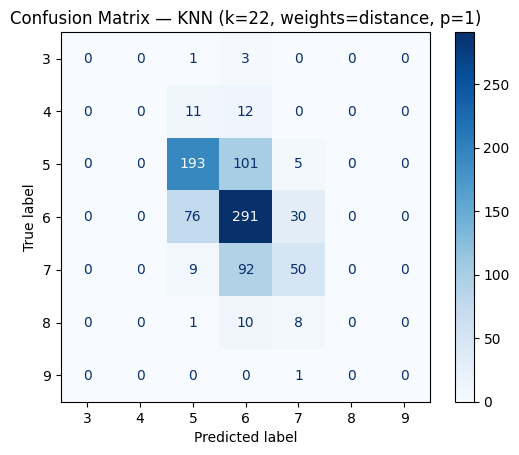


📦 Generating Kaggle submission file...
✅ Kaggle submission saved as → submission_KNN_k=22__weights=distance__p=1.csv
   id  quality
0   0        6
1   1        5
2   2        7
3   3        7
4   4        6


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [30]:
# ===============================================================
# 🧠 MODEL TRAINING AND EVALUATION (Expanded + Kaggle Submission)
# ===============================================================
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================================
# 🔹 Custom Parzen Window Classifier (Gaussian-like)
# ===============================================================
class ParzenWindowClassifier(BaseEstimator, ClassifierMixin):
    """Gaussian kernel Parzen Window Classifier (probabilistic KNN-like)."""

    def __init__(self, bandwidth=0.4, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.scaler_ = StandardScaler().fit(X)
        X_scaled = self.scaler_.transform(X)

        # Train one KDE per class
        self.kdes_ = {}
        for c in self.classes_:
            kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
            kde.fit(X_scaled[y == c])
            self.kdes_[c] = kde
        return self

    def predict(self, X):
        X_scaled = self.scaler_.transform(X)
        log_probs = np.vstack([
            self.kdes_[c].score_samples(X_scaled) for c in self.classes_
        ]).T
        preds = self.classes_[np.argmax(log_probs, axis=1)]
        return preds


# ===============================================================
# 🔧 Define Expanded Classifier Search Space
# ===============================================================
classifiers = []
classifier_names = []

# -------------------------------
# 1️⃣ Complement Naive Bayes
# -------------------------------
classifiers.append(ComplementNB())
classifier_names.append("Complement Naive Bayes")

# -------------------------------
# 2️⃣ Logistic Regression (Regularization & Solver grid)
# -------------------------------
for C in [0.01, 0.1, 0.5, 1, 5, 10, 25, 50]:
    for solver in ["lbfgs", "saga"]:
        classifiers.append(LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42))
        classifier_names.append(f"Logistic Regression (C={C}, solver={solver})")

# -------------------------------
# 3️⃣ KNN Variants (k, weights, p)
# -------------------------------
k_values = [2, 4, 6, 8, 10, 12, 15, 18, 20, 22, 24, 28, 32]
weights_options = ['uniform', 'distance']
p_values = [1, 2]  # 1=Manhattan, 2=Euclidean

for k in k_values:
    for w in weights_options:
        for p in p_values:
            classifiers.append(KNeighborsClassifier(n_neighbors=k, weights=w, p=p))
            classifier_names.append(f"KNN (k={k}, weights={w}, p={p})")

# -------------------------------
# 4️⃣ Gaussian-like Parzen (bandwidth sweep)
# -------------------------------
for bw in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]:
    classifiers.append(ParzenWindowClassifier(bandwidth=bw))
    classifier_names.append(f"Gaussian-like Parzen (bw={bw})")

# ---------------------------------------------------------------
# 🧾 Summary of Search Space
# ---------------------------------------------------------------
print(f"✅ Total models to evaluate: {len(classifiers)}")
print("Example configurations:")
for name in classifier_names[:8]:
    print("  •", name)
print("  ...")


# ===============================================================
# 🧠 Train and Evaluate All Models
# ===============================================================
results = []
trained_models = {}

for name, clf in zip(classifier_names, classifiers):
    print(f"\n🚀 Training {name}...")
    try:
        model = make_pipeline(StandardScaler(), clf) if not isinstance(clf, ParzenWindowClassifier) else clf
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_val)

        # Compute metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

        # Save results
        trained_models[name] = model
        results.append({
            "Classifier": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })

        print(f"✅ {name}: "
              f"Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

    except Exception as e:
        print(f"⚠️ Skipped {name} — error: {e}")


# ===============================================================
# 📊 Summarize Model Performance
# ===============================================================
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n📊 Final Results Summary:")
display(results_df)

best_model_name = results_df.iloc[0]["Classifier"]
best_model = trained_models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")


# ===============================================================
# 🔍 Confusion Matrix for Best Model
# ===============================================================
try:
    y_best_pred = best_model.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(y_val, y_best_pred, cmap="Blues")
    plt.title(f"Confusion Matrix — {best_model_name}")
    plt.show()
except Exception as e:
    print(f"⚠️ Could not display confusion matrix: {e}")


# ===============================================================
# 📤 Generate Kaggle Submission File
# ===============================================================
try:
    print("\n📦 Generating Kaggle submission file...")

    # Refit best model on full training data
    X_full = np.vstack([X_train, X_val])
    y_full = np.hstack([y_train, y_val])

    # Re-train best model fully
    best_model.fit(X_full, y_full)

    # Align df_test columns
    test_features = df_test[X_train.columns]

    # Predict on test data
    y_test_pred = best_model.predict(test_features)
    y_test_pred = np.round(y_test_pred).astype(int)

    # Load original test.csv (for correct id)
    original_test = pd.read_csv("data/test.csv", delimiter=';')
    submission = pd.DataFrame({
        "id": original_test["id"],
        "quality": y_test_pred
    })

    # Save CSV
    safe_name = best_model_name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "_")
    output_filename = f"submission_{safe_name}.csv"
    submission.to_csv(output_filename, index=False)

    print(f"✅ Kaggle submission saved as → {output_filename}")
    print(submission.head())

except Exception as e:
    print(f"⚠️ Could not create submission file: {e}")


## Evaluate Models

Analyze your best model's performance (see README.md for evaluation guidelines).

## Generate Predictions for Kaggle Submission

Create a CSV file with columns: `id` and `quality` (see README.md for format details).

In [137]:
# Generating Parzen Window Approximation for Kaggle 
best_m_name = "Parzen Window Approximation"
best_model = trained_models[best_m_name]

features = X_train.columns
predicted_data = df_test[features]



# Generate Predictions
y_predictions = best_model.predict(predicted_data)
predictions = pd.DataFrame({"id":predicted_data.index, "quality":y_predictions})
output = "predicted_quality_parzen_window.csv"
predictions.to_csv(output, index=False)




---
Good luck with the competition! 🍺
